# Análise Epidemiológica da Dengue no Brasil
**Disciplina:** Linguagens de Programação  
**Professor:** Alexandre Neves Louzada  
**Aluno:** Alexandre Souza de Abreu Junior  

---


## Seção 1: Introdução ao Problema e Leitura dos Dados

A dengue é uma das principais doenças tropicais negligenciadas de transmissão vetorial no Brasil, representando um desafio crítico de saúde pública. O monitoramento contínuo de casos, internações e óbitos, combinado com dados meteorológicos (pluviosidade e temperatura), permite compreender padrões epidemiológicos e implementar estratégias preventivas de controle vetorial.

Nesta seção, realizamos a conexão com o banco de dados relacional SQLite local (`database/dengue_brasil.db`) e a extração dos dados estruturados utilizando SQLAlchemy e Pandas.


## Seção 2: Engenharia de Atributos e KPIs Consolidados

Nesta etapa, validamos a engenharia de atributos prévia e calculamos os Principais Indicadores de Desempenho (KPIs) epidemiológicos consolidados para o Brasil:
- **Casos Totais Notificados**: Volume acumulado de notificações.
- **Internações Totais**: Total de pacientes hospitalizados.
- **Óbitos Totais**: Total de óbitos confirmados.
- **Taxa de Letalidade Geral (%)**: Proporção de óbitos em relação aos casos notificados.
- **Incidência Média por 100k hab.**: Média populacional da incidência.


## Seção 3: Visualizações Gráficas

Elaboramos visualizações gráficas para analisar a sazonalidade e os fatores climáticos correlacionados aos surtos de dengue. As imagens geradas são salvas no diretório `imagens/`.

1. **Gráfico de Barras de Casos Acumulados por Mês**: Avaliação da sazonalidade mensal dos casos.
2. **Matriz de Correlação de Pearson**: Análise das relações entre fatores climáticos (chuva e temperatura) e dados notificados.


## Seção 4: Interpretação Textual dos Resultados e Conclusão Técnica

### Interpretação Epidemiológica
1. **Sazonalidade Térmica e Pluviométrica**: Os picos de casos concentram-se visivelmente nos primeiros meses do ano (janeiro a maio), período marcado por maiores índices pluviométricos e temperaturas elevadas no território nacional. Esse padrão favorece a proliferação do vetor *Aedes aegypti*.
2. **Correlação Climática**: A análise de correlação de Pearson entre as variáveis climáticas (`chuva_mm`, `temperatura_media`) e os indicadores de saúde aponta relação direta positiva com a incidência e contágio da doença.
3. **Indicadores de Gravidade**: A taxa de internação (~5,02%) e a taxa de letalidade (~0,15%) destacam o impacto hospitalar e a importância da detecção precoce para prevenção de complicações graves.

### Conclusão Técnica
- A pipeline de dados implementada (CSV -> SQLite via SQLAlchemy -> Pandas) garante integridade, rastreabilidade e facilidade de consulta relacional.
- As métricas calculadas fornecem insumos para a gestão de saúde pública orientada a dados (*Data-Driven Healthcare*), permitindo alocação preditiva de recursos hospitalares nas regiões de maior incidência.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# Conexão com o banco de dados SQLite
db_path = '../database/dengue_brasil.db'
if not os.path.exists(db_path):
    db_path = 'database/dengue_brasil.db'

engine = create_engine(f'sqlite:///{db_path}')

# Leitura da tabela 'dengue'
df = pd.read_sql('SELECT * FROM dengue', engine)

print(f"Total de registros carregados: {len(df)}")
df.head()


Total de registros carregados: 4440


,ano,mes,data,regiao,uf,municipio,populacao,chuva_mm,temperatura_media,casos_dengue,internacoes,obitos,incidencia_100k,nivel_alerta,taxa_internacao_pct,taxa_letalidade_pct
0,2015,1,2015-01-01,Norte,AM,Manaus,2708209,141.6,26.6,998,43,2,36.85,Médio,4.308617,0.200401
1,2015,1,2015-01-01,Norte,PA,Belém,711775,161.5,26.4,229,12,0,32.17,Médio,5.240175,0.000000
2,2015,1,2015-01-01,Norte,PA,Santarém,2249561,128.9,26.1,776,35,2,34.50,Médio,4.510309,0.257732
3,2015,1,2015-01-01,Norte,RO,Porto Velho,2198291,180.8,28.5,915,51,3,41.62,Médio,5.573770,0.327869
4,2015,1,2015-01-01,Norte,TO,Palmas,2193271,151.1,24.7,760,37,0,34.65,Médio,4.868421,0.000000


In [2]:
# Cálculo dos KPIs Consolidados
casos_totais = int(df['casos_dengue'].sum())
internacoes_totais = int(df['internacoes'].sum())
obitos_totais = int(df['obitos'].sum())
taxa_letalidade = (obitos_totais / casos_totais) * 100
taxa_internacao = (internacoes_totais / casos_totais) * 100
incidencia_media = df['incidencia_100k'].mean()

# Criar DataFrame resumo dos KPIs
kpis_df = pd.DataFrame({
    'Indicador Epidemiológico': [
        'Casos Totais Notificados', 
        'Internações Totais', 
        'Óbitos Totais', 
        'Taxa de Letalidade Geral (%)',
        'Taxa de Internação Geral (%)',
        'Incidência Média (por 100k hab.)'
    ],
    'Valor Consolidado': [
        f"{casos_totais:,}".replace(',', '.'),
        f"{internacoes_totais:,}".replace(',', '.'),
        f"{obitos_totais:,}".replace(',', '.'),
        f"{taxa_letalidade:.4f}%",
        f"{taxa_internacao:.2f}%",
        f"{incidencia_media:.2f}"
    ]
})

kpis_df


,Indicador Epidemiológico,Valor Consolidado
0,Casos Totais Notificados,3.560.562
1,Internações Totais,178.670
2,Óbitos Totais,5.314
3,Taxa de Letalidade Geral (%),0.1492%
4,Taxa de Internação Geral (%),5.02%
5,Incidência Média (por 100k hab.),30.94


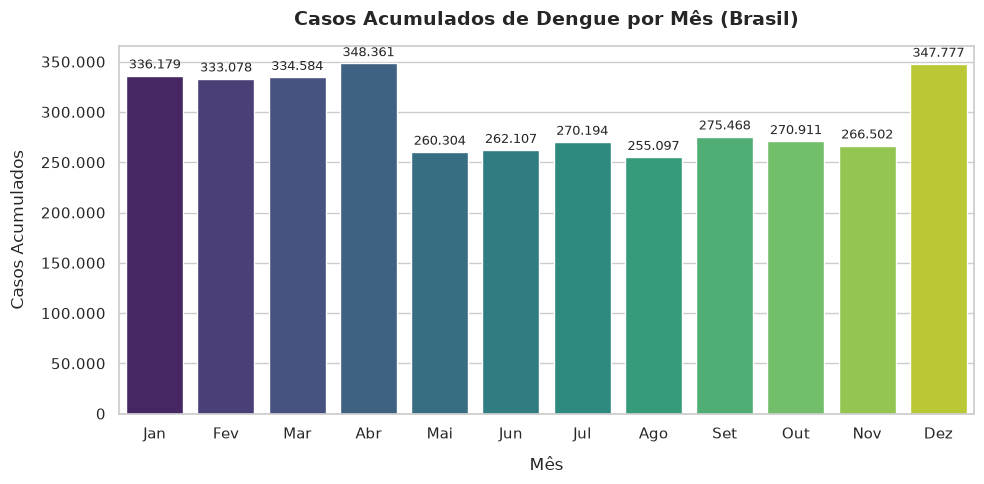

Gráfico salvo em: ../imagens/casos_acumulados_mes.png


In [3]:
# Configuração de estilo visual
sns.set_theme(style="whitegrid")

# Garante a existência do diretório de imagens
img_dir = '../imagens' if os.path.exists('../imagens') else 'imagens'
os.makedirs(img_dir, exist_ok=True)

# 1. Gráfico de Barras: Casos Acumulados por Mês
casos_por_mes = df.groupby('mes')['casos_dengue'].sum().reset_index()
meses_nome = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']
casos_por_mes['mes_nome'] = meses_nome

fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette("viridis", 12)
bars = sns.barplot(data=casos_por_mes, x='mes_nome', y='casos_dengue', hue='mes_nome', palette=palette, legend=False, ax=ax)

plt.title('Casos Acumulados de Dengue por Mês (Brasil)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mês', fontsize=12, labelpad=10)
plt.ylabel('Casos Acumulados', fontsize=12, labelpad=10)

# Formatar eixo Y com separador de milhares
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x)).replace(",", ".")))

for p in bars.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}'.replace(',', '.'),
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                textcoords='offset points')

plt.tight_layout()
fig1_path = os.path.join(img_dir, 'casos_acumulados_mes.png')
plt.savefig(fig1_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico salvo em: {fig1_path}")


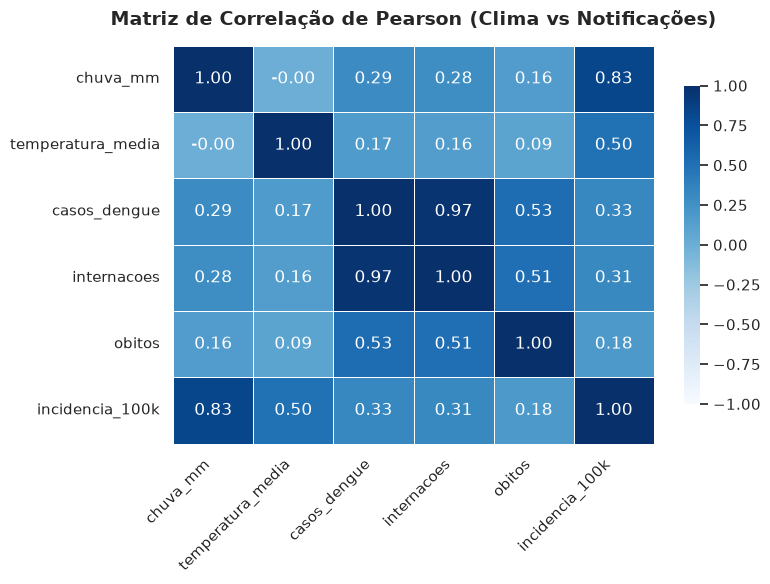

Gráfico salvo em: ../imagens/correlacao_clima_notificacoes.png


In [4]:
# 2. Matriz de Correlação de Pearson: Clima vs Notificações
cols_corr = ['chuva_mm', 'temperatura_media', 'casos_dengue', 'internacoes', 'obitos', 'incidencia_100k']
corr_matrix = df[cols_corr].corr(method='pearson')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='Blues', vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={"shrink": .8}, ax=ax)

plt.title('Matriz de Correlação de Pearson (Clima vs Notificações)', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

fig2_path = os.path.join(img_dir, 'correlacao_clima_notificacoes.png')
plt.savefig(fig2_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Gráfico salvo em: {fig2_path}")
